浏览转加购/收藏率:87.09%
加购/收藏转购买率:69.87%
整体购买转化率:67.77%
直接购买占比：10.21%


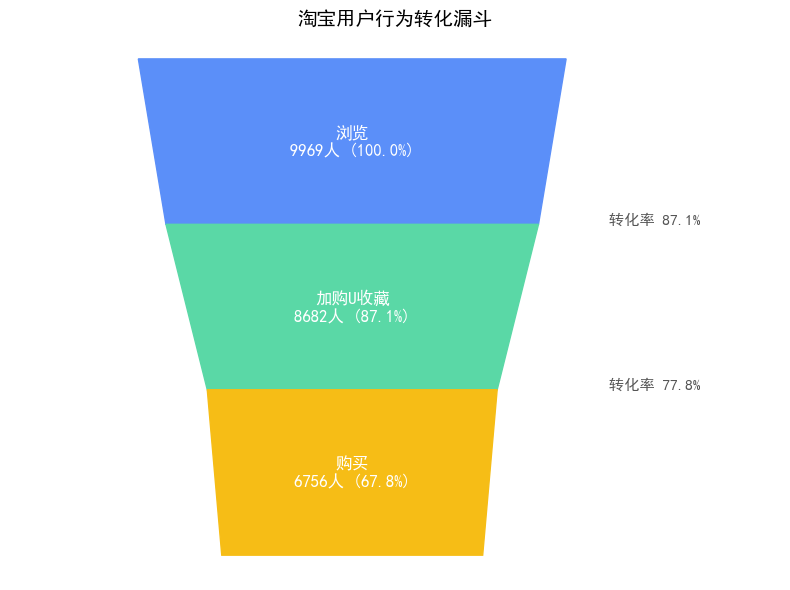

,user_id,item_id,category_id,behavior_type,timestamp,date
0,1000028,1850341,2025483,pv,2017-11-26 16:23:03,2017-11-26
1,1000028,2428956,1879194,pv,2017-11-27 08:57:46,2017-11-27
2,1000028,4717045,5071267,pv,2017-11-27 08:58:36,2017-11-27
3,1000028,5049814,3002561,pv,2017-11-27 09:09:20,2017-11-27
4,1000028,2335149,4690421,pv,2017-11-27 09:09:27,2017-11-27


,user_id,item_id,category_id,behavior_type,timestamp,date,hour
0,1000028,1850341,2025483,pv,2017-11-26 16:23:03,2017-11-26,16


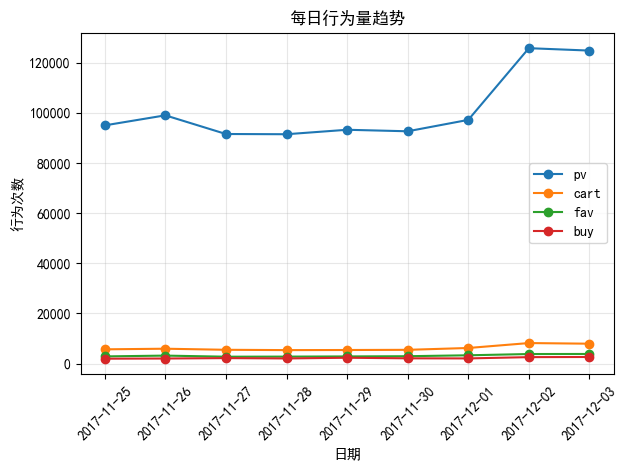

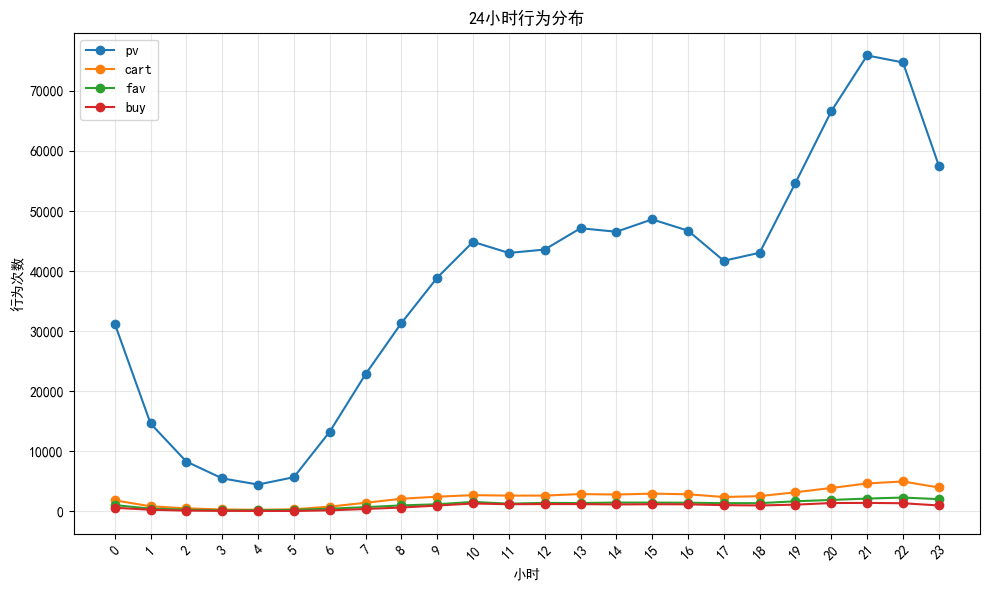

工作日日均pv: 94311
12-02/03日均pv: 125314，涨幅 32.9%
pv最高峰在21点，为白天均值的 1.7 倍


'\n时间维度结论：\n1. 按天看：11-25至12-01各行为量平稳，12-02、12-03（周六日）",pv上涨约30%，主要由周末效应贡献；数据窗口未覆盖双12预热期，\n大促对流量的影响无法在本数据中验证。\n2. 按小时看：凌晨3-5点为低谷，白天10-15点平稳，晚间20-22点为全天峰值（约为白天的1.7倍），运营活动和推送应集中在这个时段；\n3. 0点存在一个小高峰（熬夜活跃人群），可考虑针对夜间用户做定向推送。\n'

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif']=['SimHei']
rcParams['axes.unicode_minus']=False
#读取数据
df=pd.read_csv('../data/UserBehavior_clean.csv',parse_dates=['timestamp'])
#看看浏览之后，有多少用户会加购U收藏
cart_fav=['cart','fav']
cart_fav_df=df[df['behavior_type'].isin(cart_fav)]
pv_df=df[df['behavior_type']=='pv']
buy_df=df[df['behavior_type']=='buy']

buyers=set(df.loc[df['behavior_type']=='buy','user_id'])
cart_users=set(df.loc[df['behavior_type']=='cart','user_id'])
fav_users=set(df.loc[df['behavior_type']=='fav','user_id'])
direct_buy_users = buyers - cart_users - fav_users
#计算有多少用户进行了浏览
pv_counts=pv_df['user_id'].nunique()
#计算有多少用户进行了加购U收藏
cart_fav_counts=cart_fav_df['user_id'].nunique()
#计算有多少用户进行了购买
buy_counts=buy_df['user_id'].nunique()
#计算浏览转加购U收藏率
pcf_rate=(cart_fav_counts/pv_counts)*100
print(f"浏览转加购/收藏率:{pcf_rate:.2f}%")
#计算加购U收藏转购买率
cfb_rate=(len(buyers-direct_buy_users)/cart_fav_counts)*100
print(f"加购/收藏转购买率:{cfb_rate:.2f}%")
#计算整体购买转化率 购买人数 ÷ 浏览人数
bp_rate=buy_counts/pv_counts*100
print(f"整体购买转化率:{bp_rate:.2f}%")
#计算直接购买占比 未加购未收藏直接买的人数 ÷ 购买人数
# 未加购未收藏直接买的人数
b_counts = len(direct_buy_users)
bf_rate = b_counts / len(buyers) * 100
print(f"直接购买占比：{bf_rate:.2f}%")

# 第1步：准备数据（直接用你前面算好的三个数）
stages = ['浏览', '加购U收藏', '购买']          # 漏斗的三层
values = [pv_counts, cart_fav_counts, buy_counts]  # 每层的人数
rates  = [1.0, pcf_rate/100, bp_rate/100]  # 每层占浏览人数的比例
# 第2步：画图
fig, ax = plt.subplots(figsize=(8, 6))
n = len(stages)   # 一共3层
colors = ['#5B8FF9', '#5AD8A6', '#F6BD16']   # 三层的颜色：蓝、绿、黄
# 第3步：一层一层画出梯形
for i in range(n):
    # 上一层宽度 = 该层的转化率
    w_top = rates[i]
    # 下一层宽度 = 下一层的转化率（最后一层下面没有层了，稍微收窄一点）
    if i < n - 1:
        w_bot = rates[i + 1]
    else:
        w_bot = rates[i] * 0.9

    # 每层的高度位置：第1层在最上面，往下排
    y_top = -i     # 这一层的顶部
    y_bot = y_top - 1     # 这一层的底部

    # 画一个梯形：4个点（左上、右上、右下、左下），居中排列
    ax.fill([ -w_top/2, w_top/2, w_bot/2, -w_bot/2 ],
            [ y_top,  y_top,  y_bot,  y_bot  ],
            color=colors[i])

    # 在梯形中间写上：层名 + 人数 + 占比
    ax.text(0, (y_top + y_bot) / 2,
            f'{stages[i]}\n{values[i]}人 ({rates[i]:.1%})',
            ha='center', va='center',       # 文字居中
            fontsize=12, color='white', fontweight='bold')

    # 两层之间标上转化率（第二层和第三层才需要标）
    if i > 0:
        rate_text = values[i] / values[i-1]   # 这一层的上一层转化率
        ax.set_xlim(-0.8, 1.0) 
        ax.text(0.6, y_top, f'转化率 {rate_text:.1%}',
                fontsize=11, color='#555555')

# 第4步：美化
ax.set_title('淘宝用户行为转化漏斗', fontsize=14)
ax.axis('off')          # 隐藏坐标轴，漏斗图不需要
plt.tight_layout()
plt.show()
"""
浏览→加购/收藏 87.1%，意向环节健康；
有意向用户中最终购买 69.9%（严口径），约30%表达意向后未成交，是主要流失环节；
另有10.2%的购买者为直接购买（未产生加购/收藏），整体浏览→购买转化率 67.8%。
"""

#时间维度分析
display(df.head())
df['hour']=df['timestamp'].dt.hour
display(df.head(1))
#统计每天每个行为的次数
daily=df.groupby(['date','behavior_type']).size().unstack()
for col in ['pv','cart','fav','buy']:
    plt.plot(daily.index,daily[col],marker='o',label=col)
plt.title('每日行为量趋势')
plt.xlabel('日期')
plt.ylabel('行为次数')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#按小时分析（找活跃时段）
hours=df.groupby(['hour','behavior_type']).size().unstack()
plt.figure(figsize=(10,6))
for col in ['pv','cart','fav','buy']:
    plt.plot(hours.index,hours[col],marker='o',label=col)
plt.title('24小时行为分布')
plt.xlabel('小时')
plt.ylabel('行为次数')
plt.legend()
plt.xticks(range(0,24),rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 量化验证结论
pv_daily = daily['pv']
print(f"工作日日均pv: {pv_daily[:7].mean():.0f}")
print(f"12-02/03日均pv: {pv_daily[7:].mean():.0f}，涨幅 {(pv_daily[7:].mean()/pv_daily[:7].mean()-1)*100:.1f}%")

peak_hour = hours['pv'].idxmax()
day_avg = hours['pv'][10:18].mean()
print(f"pv最高峰在{peak_hour}点，为白天均值的 {hours['pv'].max()/day_avg:.1f} 倍")


#注意
"""
时间维度结论：
1. 按天看：11-25至12-01各行为量平稳，12-02、12-03（周六日）",pv上涨约30%，主要由周末效应贡献；数据窗口未覆盖双12预热期，
大促对流量的影响无法在本数据中验证。
2. 按小时看：凌晨3-5点为低谷，白天10-15点平稳，晚间20-22点为全天峰值（约为白天的1.7倍），运营活动和推送应集中在这个时段；
3. 0点存在一个小高峰（熬夜活跃人群），可考虑针对夜间用户做定向推送。
"""
